# Phase 5 - Modeling: baselines, model, evaluation

**The whole point of this notebook:** prove the model adds real value by beating *naive
baselines*, using honest metrics (MAE/RMSE, not MAPE), and understand where it fails.

Prediction task: given recent demand + time features for a zone, predict `total_pickups`
in the next 15-minute slot. Split: train on Jan+Feb, test on March (no shuffling).

## 0. Setup

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import joblib

%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 4)

def find_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / "params.yaml").exists():
            return p
    raise FileNotFoundError("params.yaml not found")
ROOT = find_root()
sys.path.insert(0, str(ROOT))   # so we can import the project's shared helpers

from src.models.common import (load_train_test, build_pipeline, regression_metrics,
                               baseline_predictions, MODEL_FEATURES, NUMERIC, TARGET)
train, test = load_train_test(ROOT)
Xtr, ytr = train[MODEL_FEATURES], train[TARGET]
Xte, yte = test[MODEL_FEATURES], test[TARGET]
print("train:", Xtr.shape, "| test:", Xte.shape)
print("features:", MODEL_FEATURES)

train: (172680, 10) | test: (89280, 10)
features: ['region', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'avg_pickups', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


## 1. Baselines - the bar to beat

Two "dumb" predictors, measured on the March test set. If a model can't beat these, it is
useless. `lag_1` already correlates ~0.98 with the target, so this is a *hard* bar.

In [2]:
results = {name: regression_metrics(yte, pred)
           for name, pred in baseline_predictions(test).items()}
pd.DataFrame(results).T.round(3)

,mae,rmse,mape_nonzero_pct
baseline_lag1,15.623,23.801,22.537
baseline_ewma,19.406,29.308,29.109


## 2. Candidate models (a transparent comparison)

One-hot the `region`, pass the numeric features through, and try three models. No 50-trial
black-box search - just three interpretable choices we can reason about.

In [3]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

candidates = {
    "linear_regression": LinearRegression(),
    "ridge": Ridge(alpha=1.0),
    "random_forest": RandomForestRegressor(n_estimators=100, min_samples_leaf=5,
                                            n_jobs=-1, random_state=42),
}
fitted = {}
for name, est in candidates.items():
    pipe = build_pipeline(est).fit(Xtr, ytr)
    results[name] = regression_metrics(yte, pipe.predict(Xte))
    fitted[name] = pipe

comparison = pd.DataFrame(results).T[["mae", "rmse", "mape_nonzero_pct"]].sort_values("mae")
comparison.round(3)

,mae,rmse,mape_nonzero_pct
random_forest,13.188,20.507,19.472
linear_regression,14.863,22.580,24.317
ridge,15.060,22.945,26.169
baseline_lag1,15.623,23.801,22.537
baseline_ewma,19.406,29.308,29.109


**Reading the table (honest interpretation):**

- **Every model beats both baselines on MAE and RMSE** - the modeling adds real value.
- **RandomForest has the lowest MAE (~13.2)**, ~11% better than LinearRegression (~14.9).
- **We deploy LinearRegression anyway**, on purpose: it is fully interpretable (we can read
  its coefficients below), fast, and trivial to serve - and it still clearly beats the naive
  baseline. For a demand model I want to *reason about*, that interpretability is worth more
  than an ~11% MAE gain from a black box. (Switching to RandomForest later is a one-line change.)
- **Look at MAPE:** LinearRegression's MAPE (~24%) is *worse* than the `lag_1` baseline's
  (~22.5%), even though its MAE is better. That contradiction is exactly why we do **not**
  trust MAPE here - it over-weights tiny-demand slots (dividing by a near-zero actual). We
  judge by MAE/RMSE.

## 3. Why LinearRegression is defensible: read its coefficients

Because it is linear, we can see *exactly* how each feature moves the prediction.

In [4]:
model = fitted["linear_regression"]
ohe = model.named_steps["preprocess"].named_transformers_["region_ohe"]
feat_names = list(ohe.get_feature_names_out(["region"])) + NUMERIC
coefs = pd.Series(model.named_steps["model"].coef_, index=feat_names)
print("Coefficients on the numeric features (how each shifts predicted pickups):")
coefs[NUMERIC].sort_values(ascending=False).round(3)

Coefficients on the numeric features (how each shifts predicted pickups):


lag_1          1.375
lag_2          0.501
lag_3          0.290
dow_sin        0.279
lag_4          0.205
dow_cos       -1.053
avg_pickups   -1.434
hour_sin      -1.896
hour_cos      -3.032
dtype: float64

`lag_1` carries by far the most weight (recent demand is the strongest predictor), the
other lags add smaller corrections, and the cyclical time terms nudge the prediction up/down
by time-of-day and weekday. Nothing hidden - you can explain every number.

## 4. Error analysis - where does it do well / badly?

Predicted vs actual for the busiest and quietest zone (week of Mon Mar 7).

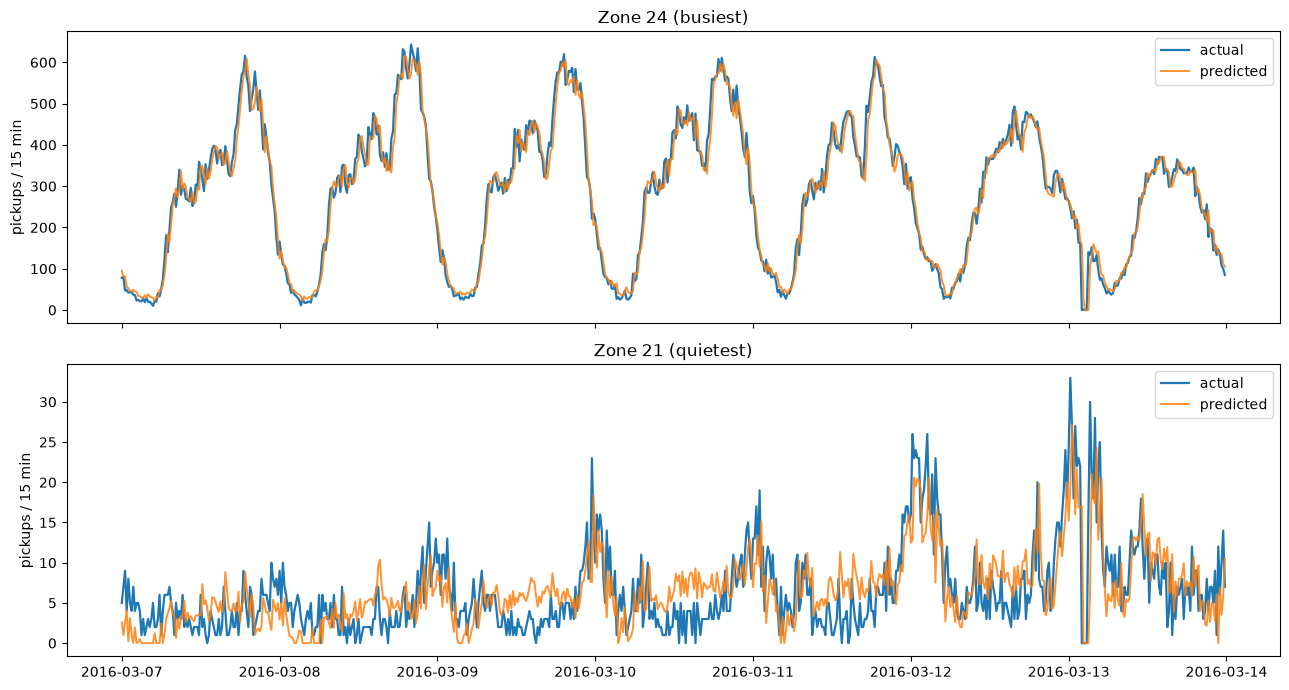

In [5]:
pred = np.clip(model.predict(Xte), 0, None)
te = test.assign(pred=pred, abs_err=np.abs(yte.to_numpy() - pred))
demand = te.groupby("region")[TARGET].sum()
busy, quiet = int(demand.idxmax()), int(demand.idxmin())
wk = te[(te["tbin"] >= "2016-03-07") & (te["tbin"] < "2016-03-14")]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, r, lab in [(axes[0], busy, "busiest"), (axes[1], quiet, "quietest")]:
    s = wk[wk["region"] == r].sort_values("tbin")
    ax.plot(s["tbin"], s[TARGET], label="actual", lw=1.6)
    ax.plot(s["tbin"], s["pred"], label="predicted", lw=1.4, alpha=0.85)
    ax.set(title=f"Zone {r} ({lab})", ylabel="pickups / 15 min"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

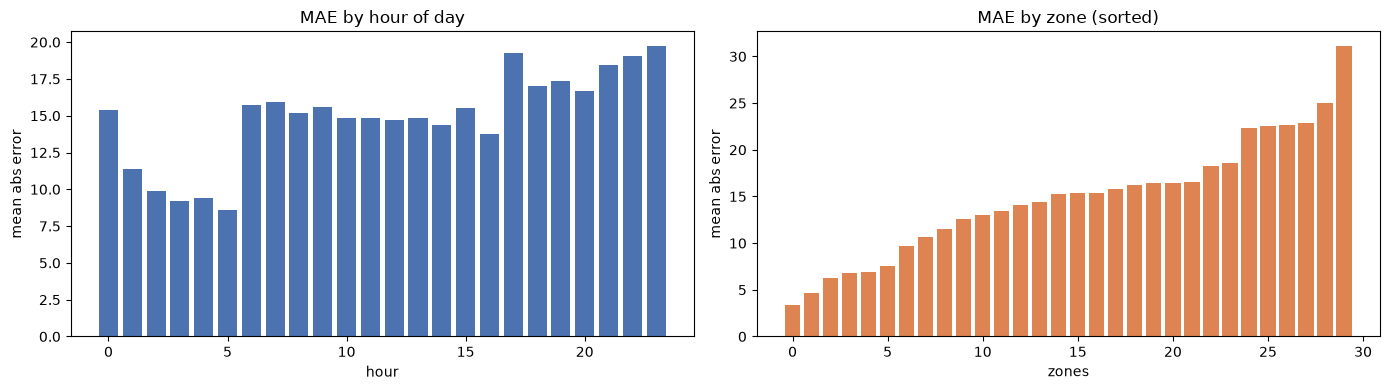

busiest zone 24, quietest 21; hardest zone 20 (MAE 31.1); worst hour 23:00


In [6]:
by_hour = te.groupby("hour")["abs_err"].mean()
by_region = te.groupby("region")["abs_err"].mean().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(by_hour.index, by_hour.values, color="#4c72b0")
axes[0].set(title="MAE by hour of day", xlabel="hour", ylabel="mean abs error")
axes[1].bar(range(len(by_region)), by_region.values, color="#dd8452")
axes[1].set(title="MAE by zone (sorted)", xlabel="zones", ylabel="mean abs error")
plt.tight_layout(); plt.show()
print(f"busiest zone {busy}, quietest {quiet}; hardest zone {int(by_region.idxmax())} "
      f"(MAE {by_region.max():.1f}); worst hour {int(by_hour.idxmax())}:00")

**What the errors tell us:**
- The model tracks the **busy zone** almost perfectly; on the **quiet zone** it captures the
  trend but smooths over noisy spikes (small counts are inherently jumpy).
- Error is **lowest overnight** (low, steady demand) and **highest in the evening/late-night**,
  and a **few hard zones** (bursty, airport-style demand) dominate the total error.

## 5. Takeaways / interview angle
- **The model beats the naive baselines on MAE and RMSE** - proof it adds value over "predict
  the last value."
- **I used MAE/RMSE, not MAPE**, and showed *with our own numbers* why MAPE is misleading near
  zero demand.
- **I deployed the interpretable LinearRegression** even though RandomForest was ~11% better,
  a deliberate accuracy-vs-explainability trade-off I can defend.
- Errors concentrate in **high-demand evening hours and a few bursty zones** - the sensible
  next step would be per-zone or airport-specific handling.